# Netflix-like Recommendations using KNN

This notebook demonstrates how to build a Netflix-style recommendation system using K-Nearest Neighbors (KNN).

## Key Concepts:
- **Item-based Collaborative Filtering**: Find similar movies based on feature vectors
- **Distance Metrics**: Euclidean and Cosine similarity
- **K-Nearest Neighbors**: Find K most similar items to recommend
- **Use Case**: "Users who liked Movie X also liked Movies Y, Z, W"

## Section 1: Import Required Libraries

In [11]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Section 2: Create Sample Movie Dataset

We'll create a small movie dataset with features like IMDB rating, duration, release year, and genre encoding.

In [12]:
# Create sample movie dataset
movies_data = {
    'Movie': [
        'Inception',      # A=Sci-Fi Action
        'Dark Knight',     # B=Action Drama
        'Interstellar',    # C=Sci-Fi Drama
        'Gladiator',       # D=Action Historical
        'Matrix',          # E=Sci-Fi Action
        'Phantom Menace',  # F=Sci-Fi Action
        'Shawshank',       # G=Drama Crime
        'Pulp Fiction',    # H=Crime Drama
    ],
    'IMDB_Rating': [8.8, 9.0, 8.6, 8.5, 8.7, 6.5, 9.3, 8.9],
    'Duration_min': [148, 152, 169, 155, 136, 136, 142, 154],
    'Release_Year': [2010, 2008, 2014, 2000, 1999, 1999, 1994, 1994],
    'Sci_Fi': [1, 0, 1, 0, 1, 1, 0, 0],      # Genre: 1=Yes, 0=No
    'Action': [1, 1, 0, 1, 1, 1, 0, 0],
    'Drama': [0, 1, 1, 0, 0, 0, 1, 1],
    'Crime': [0, 0, 0, 0, 0, 0, 1, 1],
}

movies_df = pd.DataFrame(movies_data)
print("Movie Dataset:")
print(movies_df.to_string(index=False))
print(f"\n📊 Dataset shape: {movies_df.shape}")

Movie Dataset:
         Movie  IMDB_Rating  Duration_min  Release_Year  Sci_Fi  Action  Drama  Crime
     Inception          8.8           148          2010       1       1      0      0
   Dark Knight          9.0           152          2008       0       1      1      0
  Interstellar          8.6           169          2014       1       0      1      0
     Gladiator          8.5           155          2000       0       1      0      0
        Matrix          8.7           136          1999       1       1      0      0
Phantom Menace          6.5           136          1999       1       1      0      0
     Shawshank          9.3           142          1994       0       0      1      1
  Pulp Fiction          8.9           154          1994       0       0      1      1

📊 Dataset shape: (8, 8)


## Section 3: Understand Movie Features & Normalize

Extract features and normalize them so each feature contributes equally to similarity calculations.

In [13]:
# Extract feature columns for KNN
feature_columns = ['IMDB_Rating', 'Duration_min', 'Release_Year', 'Sci_Fi', 'Action', 'Drama', 'Crime']
X = movies_df[feature_columns].values

print("Raw Feature Matrix:")
print(X)
print(f"\nFeature names: {feature_columns}")
print(f"Shape: {X.shape}")

# Normalize features (0-1 scale) for fair distance calculation
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

print("\n✓ Normalized Feature Matrix:")
print(pd.DataFrame(X_normalized, columns=feature_columns).round(3))

Raw Feature Matrix:
[[8.800e+00 1.480e+02 2.010e+03 1.000e+00 1.000e+00 0.000e+00 0.000e+00]
 [9.000e+00 1.520e+02 2.008e+03 0.000e+00 1.000e+00 1.000e+00 0.000e+00]
 [8.600e+00 1.690e+02 2.014e+03 1.000e+00 0.000e+00 1.000e+00 0.000e+00]
 [8.500e+00 1.550e+02 2.000e+03 0.000e+00 1.000e+00 0.000e+00 0.000e+00]
 [8.700e+00 1.360e+02 1.999e+03 1.000e+00 1.000e+00 0.000e+00 0.000e+00]
 [6.500e+00 1.360e+02 1.999e+03 1.000e+00 1.000e+00 0.000e+00 0.000e+00]
 [9.300e+00 1.420e+02 1.994e+03 0.000e+00 0.000e+00 1.000e+00 1.000e+00]
 [8.900e+00 1.540e+02 1.994e+03 0.000e+00 0.000e+00 1.000e+00 1.000e+00]]

Feature names: ['IMDB_Rating', 'Duration_min', 'Release_Year', 'Sci_Fi', 'Action', 'Drama', 'Crime']
Shape: (8, 7)

✓ Normalized Feature Matrix:
   IMDB_Rating  Duration_min  Release_Year  Sci_Fi  Action  Drama  Crime
0        0.326        -0.097         1.105     1.0   0.775   -1.0 -0.577
1        0.575         0.290         0.820    -1.0   0.775    1.0 -0.577
2        0.078         1.931  

## Section 4: Calculate Similarity Between Movies

We compute two types of similarity:
- **Cosine Similarity**: Measures angle between vectors (0 to 1, higher = more similar)
- **Euclidean Distance**: Measures straight-line distance (lower = more similar)

In [4]:
# Compute Cosine Similarity Matrix
cosine_sim = cosine_similarity(X_normalized)
cosine_sim_df = pd.DataFrame(cosine_sim, 
                              index=movies_df['Movie'], 
                              columns=movies_df['Movie'])

print("Cosine Similarity Matrix (0.0 to 1.0):")
print(cosine_sim_df.round(3))

# Example: Similarity of 'Inception' (A) with other movies
print("\n" + "="*60)
print("📌 Example: Similarity scores for 'Inception':")
print("="*60)
inception_similarity = cosine_sim_df['Inception'].sort_values(ascending=False)
for movie, sim in inception_similarity.items():
    print(f"{movie:20s} → {sim:.3f}")

# Interpret results
print("\n💡 Interpretation:")
print("- Inception (Sci-Fi Action) is most similar to:")
print("  • Movies with similar features (rating, duration, genres)")
print("  • Dark Knight (Action Drama) - both high-rated action movies")
print("  • Matrix (Sci-Fi Action) - same genres")

Cosine Similarity Matrix (0.0 to 1.0):
Movie           Inception  Dark Knight  Interstellar  Gladiator  Matrix  \
Movie                                                                     
Inception           1.000       -0.000         0.153      0.134   0.578   
Dark Knight        -0.000        1.000         0.201      0.220  -0.387   
Interstellar        0.153        0.201         1.000     -0.350  -0.543   
Gladiator           0.134        0.220        -0.350      1.000   0.086   
Matrix              0.578       -0.387        -0.543      0.086   1.000   
Phantom Menace      0.249       -0.488        -0.375      0.077   0.578   
Shawshank          -0.777       -0.100        -0.255     -0.365  -0.361   
Pulp Fiction       -0.864       -0.097        -0.036     -0.255  -0.624   

Movie           Phantom Menace  Shawshank  Pulp Fiction  
Movie                                                    
Inception                0.249     -0.777        -0.864  
Dark Knight             -0.488     -

## Section 5: Implement KNN for Recommendations

Train a KNN model using Euclidean distance to find the K nearest neighbors for any movie.

In [5]:
# Initialize KNN model
n_neighbors = 4  # Find 4 nearest neighbors (including the movie itself)
knn_model = NearestNeighbors(n_neighbors=n_neighbors, algorithm='auto', metric='euclidean')
knn_model.fit(X_normalized)

print(f"✓ KNN Model trained with {n_neighbors} neighbors")
print(f"  Metric: Euclidean distance")
print(f"  Algorithm: auto")

✓ KNN Model trained with 4 neighbors
  Metric: Euclidean distance
  Algorithm: auto


## Section 6: Find Nearest Neighbors

Query the KNN model to find the K closest movies for a selected movie.

In [6]:
# Function to find nearest neighbors for a movie
def find_neighbors(movie_name, k=4):
    """Find K nearest neighbors for a given movie"""
    
    # Get movie index
    if movie_name not in movies_df['Movie'].values:
        print(f"❌ Movie '{movie_name}' not found in dataset")
        return None
    
    movie_idx = movies_df[movies_df['Movie'] == movie_name].index[0]
    movie_vector = X_normalized[movie_idx].reshape(1, -1)
    
    # Find distances and indices
    distances, indices = knn_model.kneighbors(movie_vector)
    
    return distances[0], indices[0], movie_idx

# Example 1: Find neighbors of 'Inception'
print("="*70)
print("🎬 EXAMPLE: Find neighbors of 'Inception'")
print("="*70)

distances, indices, _ = find_neighbors('Inception', k=4)

print(f"\n📊 Results (Euclidean Distance):")
print(f"{'Rank':<6} {'Movie':<20} {'Distance':<12} {'Similarity'}")
print("-"*70)

result_df = pd.DataFrame({
    'Movie': movies_df.iloc[indices]['Movie'].values,
    'Distance': distances,
})
result_df['Similarity'] = (1 / (1 + result_df['Distance'])).round(3)  # Convert distance to similarity

for i, row in enumerate(result_df.itertuples(), 1):
    marker = "🎯 (Query)" if i == 1 else "⭐ (Recommend)"
    print(f"{i:<6} {row.Movie:<20} {row.Distance:<12.4f} {row.Similarity:<.3f}  {marker}")

🎬 EXAMPLE: Find neighbors of 'Inception'

📊 Results (Euclidean Distance):
Rank   Movie                Distance     Similarity
----------------------------------------------------------------------
1      Inception            0.0000       1.000  🎯 (Query)
2      Matrix               1.9540       0.339  ⭐ (Recommend)
3      Gladiator            2.5747       0.280  ⭐ (Recommend)
4      Dark Knight          2.8796       0.258  ⭐ (Recommend)


## Section 7: Generate Movie Recommendations

Create a recommendation engine function that returns top recommendations for any movie.

In [7]:
# Recommendation Engine
class NetflixRecommender:
    """KNN-based movie recommendation system"""
    
    def __init__(self, movies_df, X_normalized, knn_model):
        self.movies_df = movies_df
        self.X_normalized = X_normalized
        self.knn_model = knn_model
    
    def recommend(self, movie_name, num_recommendations=3):
        """Get top N recommendations for a movie (excluding the movie itself)"""
        
        # Get the movie index
        if movie_name not in self.movies_df['Movie'].values:
            return None
        
        movie_idx = self.movies_df[self.movies_df['Movie'] == movie_name].index[0]
        movie_vector = self.X_normalized[movie_idx].reshape(1, -1)
        
        # Query KNN (get more neighbors to exclude the query movie)
        distances, indices = self.knn_model.kneighbors(movie_vector, n_neighbors=num_recommendations+1)
        
        # Exclude the first result (the movie itself)
        distances = distances[0][1:]
        indices = indices[0][1:]
        
        # Get movie info
        recommended_movies = self.movies_df.iloc[indices].copy()
        recommended_movies['Distance'] = distances
        recommended_movies['Similarity_Score'] = (1 / (1 + distances)).round(3)
        
        return recommended_movies[['Movie', 'IMDB_Rating', 'Distance', 'Similarity_Score']]

# Create recommender instance
recommender = NetflixRecommender(movies_df, X_normalized, knn_model)

# Generate recommendations for multiple movies
test_movies = ['Inception', 'Shawshank', 'Matrix']

print("\n" + "="*70)
print("🎥 NETFLIX RECOMMENDATION ENGINE")
print("="*70)

for movie in test_movies:
    print(f"\n🎬 If you liked '{movie}':")
    print("-" * 70)
    recommendations = recommender.recommend(movie, num_recommendations=3)
    print(recommendations.to_string(index=False))
    print()


🎥 NETFLIX RECOMMENDATION ENGINE

🎬 If you liked 'Inception':
----------------------------------------------------------------------
      Movie  IMDB_Rating  Distance  Similarity_Score
     Matrix          8.7  1.953991             0.339
  Gladiator          8.5  2.574673             0.280
Dark Knight          9.0  2.879635             0.258


🎬 If you liked 'Shawshank':
----------------------------------------------------------------------
       Movie  IMDB_Rating  Distance  Similarity_Score
Pulp Fiction          8.9  1.260881             0.442
 Dark Knight          9.0  3.828339             0.207
   Gladiator          8.5  4.110512             0.196


🎬 If you liked 'Matrix':
----------------------------------------------------------------------
         Movie  IMDB_Rating  Distance  Similarity_Score
     Inception          8.8  1.953991             0.339
     Gladiator          8.5  2.729119             0.268
Phantom Menace          6.5  2.734357             0.268



## Section 8: Visualize Recommendation Results

Create visualizations to show selected movie and its recommended neighbors.

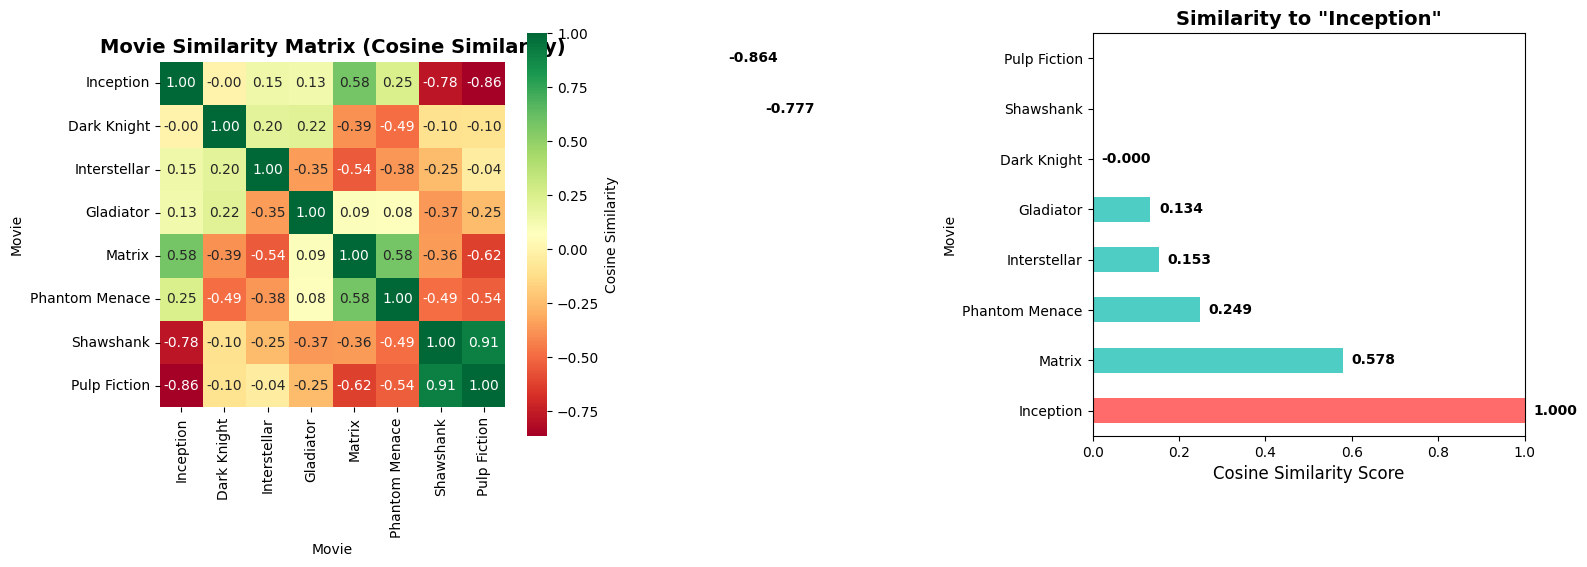

✓ Visualization 1: Similarity Matrix Heatmap


In [8]:
# Visualization 1: Heatmap of Cosine Similarity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Similarity heatmap
sns.heatmap(cosine_sim_df, annot=True, fmt='.2f', cmap='RdYlGn', 
            square=True, cbar_kws={'label': 'Cosine Similarity'}, ax=axes[0])
axes[0].set_title('Movie Similarity Matrix (Cosine Similarity)', fontsize=14, fontweight='bold')

# Inception similarity bar chart
inception_similarity = cosine_sim_df['Inception'].sort_values(ascending=False)
colors = ['#FF6B6B' if m == 'Inception' else '#4ECDC4' for m in inception_similarity.index]
inception_similarity.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Cosine Similarity Score', fontsize=12)
axes[1].set_title('Similarity to "Inception"', fontsize=14, fontweight='bold')
axes[1].set_xlim([0, 1])

for i, v in enumerate(inception_similarity):
    axes[1].text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualization 1: Similarity Matrix Heatmap")

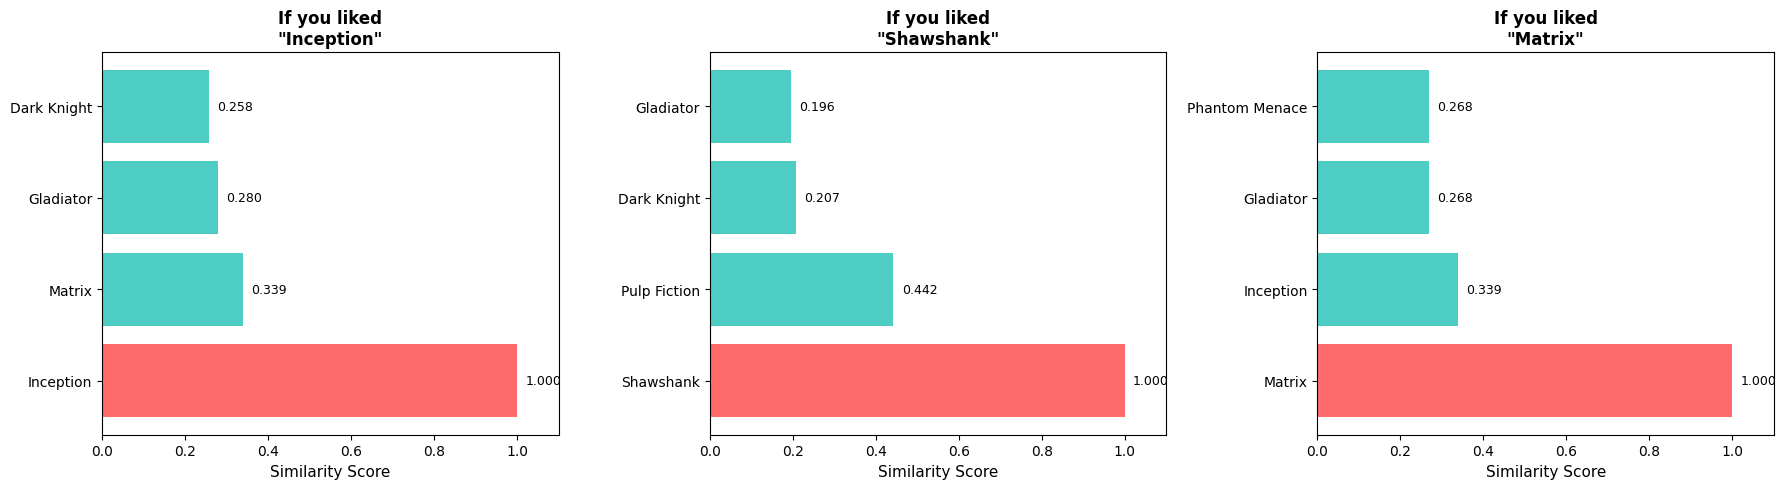

✓ Visualization 2: Multi-Query Recommendations


In [9]:
# Visualization 2: Recommendations for multiple query movies
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
query_movies = ['Inception', 'Shawshank', 'Matrix']

for idx, query_movie in enumerate(query_movies):
    distances, indices, query_idx = find_neighbors(query_movie, k=4)
    rec_movies = movies_df.iloc[indices]
    similarities = 1 / (1 + distances)
    
    colors = ['#FF6B6B' if i == query_idx else '#4ECDC4' for i in indices]
    
    axes[idx].barh(rec_movies['Movie'], similarities, color=colors)
    axes[idx].set_xlabel('Similarity Score', fontsize=11)
    axes[idx].set_title(f'If you liked\n"{query_movie}"', fontsize=12, fontweight='bold')
    axes[idx].set_xlim([0, 1.1])
    
    # Add value labels
    for i, v in enumerate(similarities):
        axes[idx].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Visualization 2: Multi-Query Recommendations")

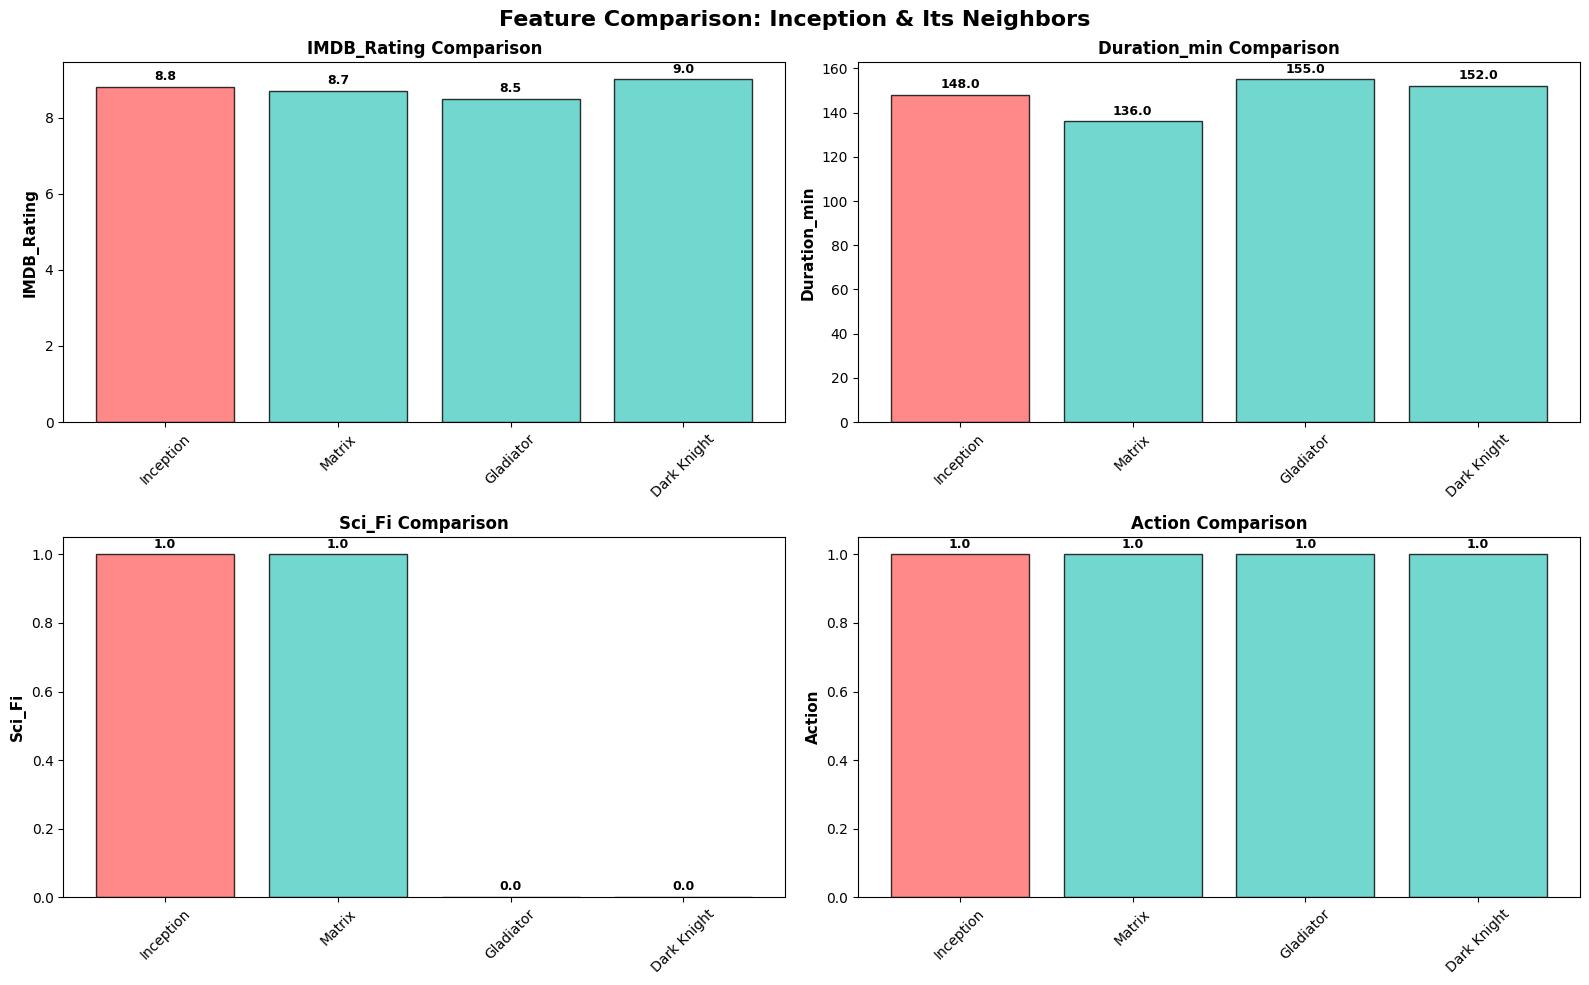

✓ Visualization 3: Feature Comparison of Movie Neighbors


In [10]:
# Visualization 3: Feature Comparison - Inception vs Recommendations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Feature Comparison: Inception & Its Neighbors', fontsize=16, fontweight='bold')

# Get Inception neighbors
distances, indices, inception_idx = find_neighbors('Inception', k=4)
featured_movies = movies_df.iloc[indices]

# Select 4 key features to visualize
key_features = ['IMDB_Rating', 'Duration_min', 'Sci_Fi', 'Action']

for idx, feature in enumerate(key_features):
    row = idx // 2
    col = idx % 2
    
    values = featured_movies[feature]
    colors = ['#FF6B6B' if i == inception_idx else '#4ECDC4' for i in indices]
    
    axes[row, col].bar(featured_movies['Movie'], values, color=colors, alpha=0.8, edgecolor='black')
    axes[row, col].set_ylabel(feature, fontsize=11, fontweight='bold')
    axes[row, col].set_title(f'{feature} Comparison', fontsize=12, fontweight='bold')
    axes[row, col].tick_params(axis='x', rotation=45)
    
    # Add value labels
    for i, v in enumerate(values):
        axes[row, col].text(i, v + max(values)*0.02, f'{v:.1f}', 
                           ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualization 3: Feature Comparison of Movie Neighbors")

## Summary: How Netflix KNN Works 🎬

### Algorithm Steps:
1. **Feature Extraction**: Create vectors for each movie (rating, duration, genres, year)
2. **Normalization**: Scale features to 0-1 range (StandardScaler)
3. **Similarity Computation**: Calculate distance/similarity between all movie pairs
   - Cosine Similarity: Range [0, 1] → higher = more similar
   - Euclidean Distance: Lower distance = more similar
4. **KNN Query**: For a query movie, find K nearest neighbors
5. **Recommendation**: Return the K neighbors (excluding query) as recommendations

### Real-World Netflix Implementation:
- **Scale**: Netflix uses hundreds of millions of movies/shows
- **Features**: User ratings, watch history, explicit/implicit signals
- **Hybrid**: Combines item-based KNN with collaborative filtering
- **Production**: Uses approximate nearest neighbors (Annoy, FAISS) for speed
- **Regularization**: Cold-start solutions for new items/users

### Key Advantages:
✅ Interpretable (can explain why item is recommended)
✅ Fast at inference time (precompute similarities)
✅ Works with any feature type (numerical, categorical)
✅ Simple baseline for production systems

### Limitations:
❌ Data sparsity (user ratings are sparse)
❌ Cold-start problem (new items have no neighbors)
❌ Doesn't learn from patterns (purely distance-based)
❌ Needs all features for all items

## 🚀 Next Steps & Exercises

### Try These Variations:
1. **Change K values**: Experiment with K=1, 3, 5, 10 and observe how recommendations change
2. **Different metrics**: Try 'cosine', 'manhattan', 'minkowski' instead of 'euclidean'
3. **Feature weighting**: Give more importance to ratings than duration
4. **User-based filtering**: Build user-user similarity instead of item-item
5. **Hybrid approach**: Combine KNN with matrix factorization (SVD)

### Real Dataset Ideas:
- MovieLens 100K dataset: https://grouplens.org/datasets/movielens/
- Netflix Prize dataset (historical)
- IMDb dataset
- Your own rating data!

### Advanced Techniques:
- Approximate Nearest Neighbors (Annoy, FAISS) for millions of items
- Collaborative filtering (user ratings as features)
- Content-based + Collaborative filtering (hybrid)
- Deep learning embeddings (word2vec for movies)
- Reinforcement learning for personalization